<a href="https://colab.research.google.com/github/Wanjala-B/Machine-Learning-Classification-/blob/main/Classification_in_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Handwritten Digit Classification Project

This repository documents a machine learning project focused on classifying handwritten digits using the MNIST dataset. The goal is to build and evaluate models capable of accurately identifying digits from images. This notebook serves as a step-by-step guide through data loading, exploration, preprocessing, model training, and evaluation.

In [6]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml("mnist_784", version=1)
mnist.keys()



dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [7]:
X, y = mnist["data"], mnist["target"]
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (70000, 784)
y shape: (70000,)


In [8]:
!pip install matplotlib

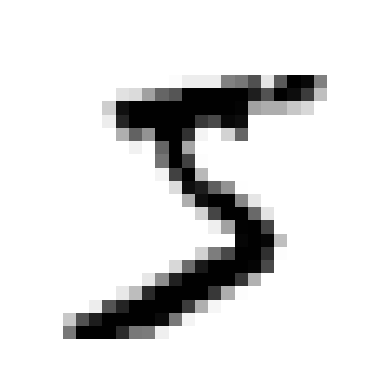

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

some_digit = X.iloc[0]
some_digit_image = some_digit.values.reshape(28,28)

plt.imshow(some_digit_image, cmap="binary")

plt.axis("off")
plt.show()

In [10]:
y[0]

'5'

## Data Loading and Initial Exploration

We begin by loading the MNIST dataset, which consists of 70,000 small images of handwritten digits. Each image is 28x28 pixels. The dataset is fetched using `sklearn.datasets.fetch_openml`.

The dataset provides pixel data (`data`) and corresponding labels (`target`). We've explored the dataset keys to understand its structure.

To get a visual understanding of the data, we've displayed the first digit from the dataset by reshaping its 784 pixel values (28x28) into a 2D array and using `matplotlib` to plot it. As observed, the first digit is a '5'.

In [11]:
y = y.astype(np.uint8)
y

,class
0,5
1,0
2,4
3,1
4,9
...,...
69995,2
69996,3
69997,4
69998,5


After visualizing the first digit, we confirmed its label by inspecting `y[0]`, which showed '5'. This confirms that our visual representation matches the corresponding label.

Furthermore, we converted the `y` (target) Series to `np.uint8`. This is a common practice for classification tasks as it optimizes memory usage and ensures that the labels are represented as efficient integer types, suitable for machine learning models that expect numerical class labels.

In [12]:
X_train, X_test, y_train, y_test= X[:60000], X[60000:], y[:60000], y[60000:]

## Data Splitting: Training and Test Sets

To evaluate the performance of our machine learning models, it's essential to split the dataset into two main parts: a training set and a test set.

*   **Training Set (X_train, y_train):** This portion of the data (the first 60,000 instances) is used to train our models. The model learns patterns and relationships from these examples.
*   **Test Set (X_test, y_test):** This unseen portion of the data (the last 10,000 instances) is used to evaluate how well our trained model generalizes to new, previously unseen examples. This helps us assess the model's performance and avoid overfitting.

By keeping the test set separate during training, we can get an unbiased estimate of the model's true performance.

In [13]:

y_train_5 = (y_train == 5) # This creates a binary target for '5's
y_test_5 = (y_test == 5)   # This creates a binary target for '5's in the test set

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5) # Train the classifier to detect '5's using the binary target

# The prediction will now be True (is a 5) or False (is not a 5)
print(sgd_clf.predict(some_digit.to_frame().T))

[ True]


## Training a Binary Classifier for '5's

In this section, a've trained an `SGDClassifier` to act as a binary classifier, specifically designed to detect whether a given digit is a '5' or not.

*   **Target Preparation:** We created `y_train_5` and `y_test_5` by converting the original `y_train` and `y_test` labels into boolean arrays, where `True` indicates a '5' and `False` indicates any other digit. This is crucial for binary classification.
*   **Model Initialization and Training:** An `SGDClassifier` (Stochastic Gradient Descent Classifier) was initialized and then trained (`fit`) using `X_train` (the training image data) and `y_train_5` (our binary '5' target).
*   **Prediction:** We then used the trained classifier to predict on `some_digit` (which is known to be a '5'). The model correctly predicted `True`, indicating it recognized the digit as a '5'. I also ensured that the input to `predict` was a DataFrame to maintain feature name consistency.

In [14]:

y_train_7 = (y_train == 7)
y_test_7 = (y_test == 7)

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_7)


print(sgd_clf.predict(some_digit.to_frame().T))

[False]


## Training a Binary Classifier for '7's

This section mirrors the previous one, but with the goal of training a binary classifier to detect '7's.

*   **Target Preparation:** Similar to `y_train_5`, I created `y_train_7` and `y_test_7` to represent a binary target for the digit '7'.
*   **Model Initialization and Training:** Another `SGDClassifier` was initialized and trained on `X_train` with `y_train_7` as the target, making it a '7' vs. not-'7' classifier.
*   **Prediction:** When the classifier predicted on `some_digit` (which is a '5'), it correctly returned `False`, indicating that `some_digit` is not a '7'. This confirms the model's ability to differentiate the target digit.

## Resources

This project leverages several key resources and libraries for machine learning and data analysis:

*   **Scikit-learn:** A comprehensive Python library for machine learning, providing tools for classification, regression, clustering, and more. It is used here for data loading (`fetch_openml`), model selection (`SGDClassifier`, `cross_val_score`, `StratifiedKFold`), and general utility (`clone`).
*   **NumPy:** The fundamental package for numerical computation in Python, essential for handling arrays and mathematical operations.
*   **Pandas:** A powerful library for data manipulation and analysis, particularly useful for working with DataFrames and Series.
*   **Matplotlib:** A widely used plotting library for creating static, animated, and interactive visualizations in Python.
*   **MNIST Dataset:** A large database of handwritten digits that is commonly used for training various image processing systems. It was loaded using Scikit-learn's `fetch_openml` function.

In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train.iloc[train_index]
    y_train_folds = y_train_5.iloc[train_index]
    X_test_fold = X_train.iloc[test_index]
    y_test_fold = y_train_5.iloc[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

0.9669
0.91625
0.96785


In [16]:
# using cross val score fuction to evaluate the SGDClassifier model using k fold cross validation with three folds.

from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

## Evaluating with `cross_val_score`

To simplify and standardize cross-validation, Scikit-Learn provides the `cross_val_score` function. This function performs K-fold cross-validation, training and evaluating the model `k` times, and returning an array of the evaluation scores.

In this cell:

*   We used `cross_val_score` with our `sgd_clf` (trained to detect '5's), the training data (`X_train`), and the binary target for '5's (`y_train_5`).
*   `cv=3` specifies 3-fold cross-validation, meaning the training set is split into 3 folds, and the model is trained on 2 folds and evaluated on the remaining fold, repeating this process three times.
*   `scoring="accuracy"` indicates that the performance metric we are interested in is accuracy.

The output `array([0.95035, 0.96035, 0.9604 ])` shows the accuracy for each of the three folds. These results are very similar to what we got with the manual `StratifiedKFold` implementation, confirming the model's high performance.

In [17]:
from typing import Never
from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.91125, 0.90855, 0.90915])

## The `Never5Classifier` - A Baseline for Comparison

It's often useful to compare a classifier's performance against a very simple, non-learning baseline to understand if our model is actually learning anything meaningful. That's the purpose of the `Never5Classifier`:

*   **Custom Estimator:** We've defined a custom Scikit-Learn-compatible estimator called `Never5Classifier`. This classifier is intentionally simplistic.
*   **`fit` method:** The `fit` method does nothing, as this classifier doesn't actually learn from data.
*   **`predict` method:** The `predict` method *always* returns `False` for every input, meaning it *never* predicts that a digit is a '5'.

When we evaluate this `Never5Classifier` using `cross_val_score` on `X_train` and `y_train_5`:

*   The results `array([0.91125, 0.90855, 0.90915])` show an accuracy of around 91%. This might seem high for a classifier that does nothing!
*   The reason for this is that only about 9.1% of the MNIST dataset consists of '5's. If a classifier always predicts "not a 5", it will be correct approximately 90.9% of the time.

This demonstrates a crucial point: **accuracy alone can be misleading**, especially with imbalanced datasets. Our `SGDClassifier`'s accuracy of ~96% is significantly better than this baseline, indicating it genuinely learns to identify '5's.

In [21]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import fetch_openml

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
confusion_matrix(y_train_5, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

## Understanding the Confusion Matrix

The Confusion Matrix is a fundamental tool for evaluating the performance of a classification model. It provides a more detailed insight into the types of errors made by a classifier than simple accuracy alone, especially for imbalanced datasets.

Let's break down the output of your confusion matrix: `[[53892, 687], [1891, 3530]]`

This 2x2 matrix for a binary classifier (like our '5' detector) can be interpreted as follows:

*   **True Negatives (TN): `53892`**
    *   These are the instances that were *not* '5's (`y_train_5` was `False`) and the model correctly predicted them as *not* '5's (`y_train_pred` was `False`).
    *   The model correctly identified 53,892 non-'5' digits.

*   **False Positives (FP): `687`**
    *   These are the instances that were *not* '5's (`y_train_5` was `False`), but the model incorrectly predicted them as '5's (`y_train_pred` was `True`). This is also known as a **Type I error**.
    *   The model incorrectly classified 687 non-'5' digits as '5's.

*   **False Negatives (FN): `1891`**
    *   These are the instances that *were* '5's (`y_train_5` was `True`), but the model incorrectly predicted them as *not* '5's (`y_train_pred` was `False`). This is also known as a **Type II error**.
    *   The model failed to detect 1,891 actual '5's.

*   **True Positives (TP): `3530`**
    *   These are the instances that *were* '5's (`y_train_5` was `True`) and the model correctly predicted them as '5's (`y_train_pred` was `True`).
    *   The model correctly identified 3,530 actual '5's.

### Interpretation:

From these numbers, we can deduce important performance metrics:

*   **Precision**: The accuracy of positive predictions. (TP / (TP + FP)) = 3530 / (3530 + 687) ≈ 0.837 or 83.7%.
    *   When the model says it's a '5', it's correct about 83.7% of the time.

*   **Recall (Sensitivity)**: The proportion of actual positives that were correctly identified. (TP / (TP + FN)) = 3530 / (3530 + 1891) ≈ 0.651 or 65.1%.
    *   The model correctly identifies about 65.1% of all actual '5's.

*   **Accuracy**: Overall correct predictions (TN + TP) / Total = (53892 + 3530) / (53892 + 687 + 1891 + 3530) ≈ 0.957 or 95.7%.
    *   This confirms the high accuracy we observed earlier with `cross_val_score`, but the precision and recall provide a more nuanced view of the model's strengths and weaknesses for detecting '5's.

In [20]:
y_train_perfect_predictions = y_train_5 #we take this as a peferction
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

## Confusion Matrix for Perfect Predictions

To better understand what a truly perfect classifier would look like, I calculated a confusion matrix using `y_train_5` against itself (`y_train_perfect_predictions = y_train_5`).

The output is `[[54579, 0], [0, 5421]]`.

Let's interpret this ideal scenario:

*   **True Negatives (TN): `54579`**
    *   All instances that were *not* '5's (54,579 of them) were correctly identified as *not* '5's. There are no false alarms here.

*   **False Positives (FP): `0`**
    *   There are zero instances where a non-'5' was incorrectly classified as a '5'. This means perfect precision for non-'5's.

*   **False Negatives (FN): `0`**
    *   There are zero instances where an actual '5' was missed. This means perfect recall for '5's.

*   **True Positives (TP): `5421`**
    *   All instances that *were* '5's (5,421 of them) were correctly identified as '5's. This is the total count of actual '5's in the training set.

### Comparison with `SGDClassifier`'s Confusion Matrix:

Recall our `SGDClassifier`'s confusion matrix: `[[53892, 687], [1891, 3530]]`

By comparing the two, we can clearly see the errors our `SGDClassifier` makes:

*   **False Positives:** The `SGDClassifier` had 687 false positives, meaning it incorrectly identified 687 non-'5's as '5's. The perfect classifier has 0.
*   **False Negatives:** The `SGDClassifier` had 1891 false negatives, meaning it missed 1891 actual '5's. The perfect classifier has 0.

This comparison highlights the areas where our model can be improved, specifically in reducing both types of errors to get closer to the ideal performance.

In [28]:
#precision and recall
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5, y_train_pred)


0.8370879772350012

### Precision Score

The `precision_score` function calculates the precision of your classifier. Precision answers the question: "When your model predicts a positive class (in this case, a '5'), how often is it correct?"

**Calculation:** `Precision = True Positives / (True Positives + False Positives)`

Your model's precision score is `0.837` or **83.7%**.

This means that when your `SGDClassifier` predicts that an image is a '5', it is correct about 83.7% of the time. While this is a good score, it indicates there are still some false positives (non-'5's incorrectly classified as '5's) that reduce its perfect reliability.

In [27]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

### Recall Score (Sensitivity)

The `recall_score` function calculates the recall (also known as sensitivity or true positive rate) of your classifier. Recall answers the question: "Out of all the actual positive cases (all the actual '5's), how many did your model correctly identify?"

**Calculation:** `Recall = True Positives / (True Positives + False Negatives)`

Your model's recall score is `0.651` or **65.1%**.

This means that your `SGDClassifier` successfully detects about 65.1% of all the actual '5's present in the dataset. A lower recall score suggests that the model is missing a significant number of actual '5's (false negatives).

In [29]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

### F1-Score

The `f1_score` function calculates the F1-score, which is the harmonic mean of precision and recall. It's particularly useful when you need a balance between precision and recall, especially with uneven class distributions.

**Calculation:** `F1-Score = 2 * (Precision * Recall) / (Precision + Recall)`

Your model's F1-score is `0.733` or **73.3%**.

The F1-score provides a single metric that balances both precision and recall. An F1-score closer to 1 indicates a better balance and overall performance, considering both false positives and false negatives. Your model's F1-score of 0.733 suggests a reasonable balance, though there's certainly room for improvement to boost both precision and recall.

In [30]:
#precision/recall trade-off
y_scores = sgd_clf.decision_function([some_digit])
y_scores

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([2164.22030239])

In [36]:
threshold=0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [35]:
threshold=90000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

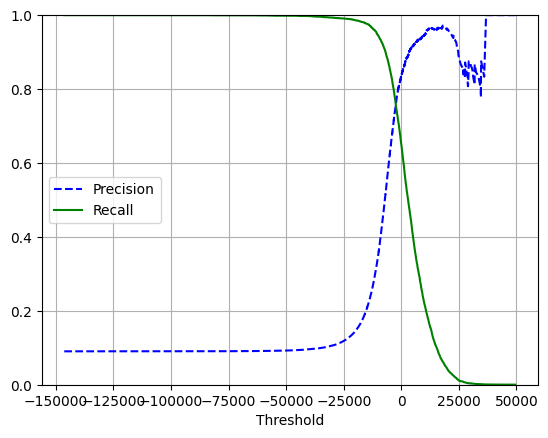

In [41]:
#deciding the right threshold
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv = 3, method="decision_function")
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.xlabel("Threshold")
    plt.legend(loc="center left")
    plt.ylim([0, 1])
    plt.grid(True)
    plt.show()

plot_precision_recall_vs_threshold(precisions, recalls, thresholds)

### Precision/Recall Trade-off Visualization

The graph above, generated by `plot_precision_recall_vs_threshold`, illustrates the crucial **precision/recall trade-off** for `SGDClassifier`.

*   **X-axis (Threshold):** Represents the decision threshold used by the classifier. The `sgd_clf.decision_function()` returns a score for each instance, and if this score is above the threshold, the instance is classified as a '5'.

*   **Blue Dashed Line (Precision):** Shows how precision changes as the threshold increases. Initially, with very low (or negative) thresholds, precision is low, meaning the model makes many false positive predictions. As the threshold increases, the model becomes more conservative, only classifying instances as '5's when it's very confident. This leads to higher precision.

*   **Green Solid Line (Recall):** Shows how recall changes as the threshold increases. With very low thresholds, the model classifies almost everything as a '5', resulting in high recall (it catches most actual '5's). As the threshold increases, the model misses more actual '5's (more false negatives), causing recall to drop.

#### Key Observations:

1.  **Inverse Relationship:** You can clearly see that as precision goes up, recall generally goes down, and vice-versa. This is the essence of the trade-off.
2.  **Choosing a Threshold:** Depending on your specific application, you might prioritize precision (e.g., if false positives are very costly, like in medical diagnoses) or recall (e.g., if false negatives are very costly, like in fraud detection). You would choose a threshold that gives you the best balance for your needs. For instance, to achieve 90% precision, you would find the point on the blue curve corresponding to 0.9 precision and then find the associated threshold value on the x-axis.
3.  **The 'Sweet Spot':** There's often a point where precision and recall meet or cross, indicating a potential good balance. However, the optimal threshold is always context-dependent.

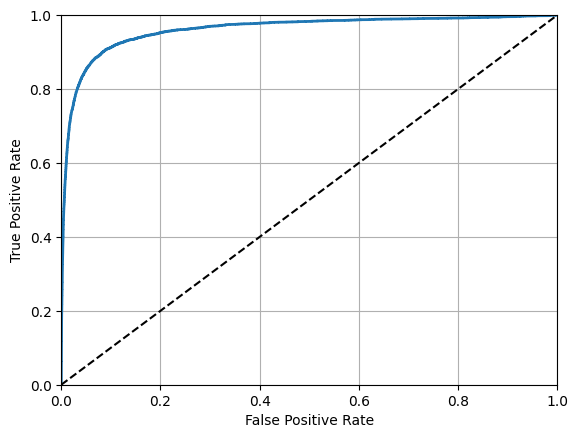

In [42]:
#ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.grid(True)
    plt.show()

plot_roc_curve(fpr, tpr)
#

### Receiver Operating Characteristic (ROC) Curve

The ROC curve is another common tool used with binary classifiers. It plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** at various threshold settings.

*   **True Positive Rate (TPR) / Recall:** This is the proportion of positive instances that are correctly detected by the classifier (`TP / (TP + FN)`).

*   **False Positive Rate (FPR):** This is the proportion of negative instances that are incorrectly classified as positive (`FP / (FP + TN)`).

*   **Thresholds:** As with the precision/recall curve, the ROC curve is generated by varying the decision threshold of the classifier.

#### Interpreting the ROC Curve:

1.  **Ideal Classifier:** A perfect classifier would have a TPR of 1 and an FPR of 0, meaning it would correctly identify all positive cases and have no false positives. Its ROC curve would go straight up from (0,0) to (0,1) and then straight across to (1,1).

2.  **Random Classifier:** A purely random classifier would produce a diagonal line from (0,0) to (1,1). This line represents a classifier that performs no better than random guessing.

3.  **Better Classifiers:** Good classifiers stay as far away from the diagonal line as possible, towards the top-left corner of the plot. The larger the area under the curve (AUC), the better the classifier's performance.

#### Area Under the Curve (AUC)

Often, the **Area Under the ROC Curve (AUC)** is used as a summary metric. An AUC of 1 represents a perfect classifier, while an AUC of 0.5 represents a random classifier. A higher AUC indicates that the model is better at distinguishing between positive and negative classes.



In [43]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

np.float64(0.9604938554008616)

### ROC AUC Score

The `roc_auc_score` function calculates the Area Under the Receiver Operating Characteristic (ROC) Curve. As discussed in the previous section, the AUC is a single number that summarizes the overall performance of a binary classifier across all possible classification thresholds.

Your model's ROC AUC score is `0.9605`.

#### Interpretation:

*   An AUC of 1.0 represents a perfect classifier that has 100% true positive rate and 0% false positive rate (i.e., it perfectly distinguishes between positive and negative classes).
*   An AUC of 0.5 represents a random classifier (i.e., it performs no better than chance).

Your `SGDClassifier`'s ROC AUC score of **0.9605** is quite high. This indicates that the model is very good at distinguishing between '5's and non-'5's. It suggests that there's a strong separation between the positive and negative classes based on the decision function scores provided by your model.

Comparing this to the visual representation of the ROC curve, a high AUC corresponds to the curve staying close to the top-left corner of the plot, which means the model has a high true positive rate for low false positive rates.

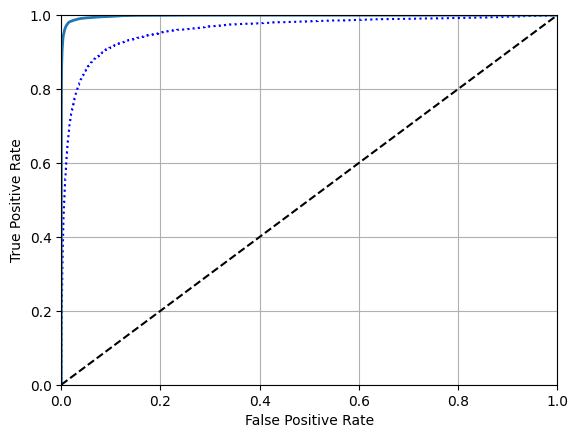

/tmp/ipykernel_4426/2324789281.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


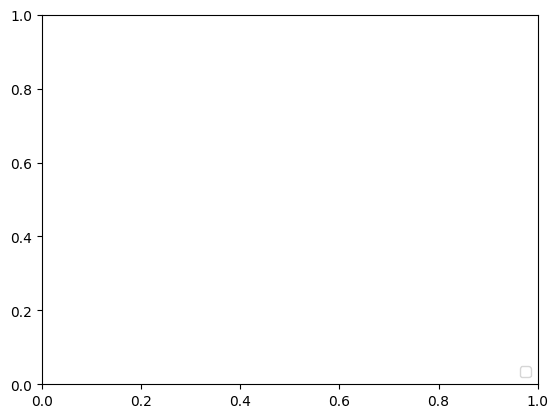

In [44]:
#trying doing randomforest classifier and compare it to ROC
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")
y_scores_forest = y_probas_forest[:, 1] # score = proba of positive class
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5, y_scores_forest)

plt.plot(fpr, tpr, "b:", label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc="lower right")
plt.show()

In [45]:
roc_auc_score(y_train_5, y_scores_forest)

np.float64(0.9983436731328145)

### Comparing `RandomForestClassifier` with `SGDClassifier` using ROC AUC

Have now trained a `RandomForestClassifier` and evaluated its performance using the ROC AUC score, which is `0.9983`.

Let's compare this to the `SGDClassifier`'s ROC AUC score of `0.9605`.

#### Interpretation:

*   **`RandomForestClassifier` AUC: `0.9983`**
    *   This is an extremely high AUC score, very close to the perfect score of 1.0. It indicates that the Random Forest model is exceptionally good at distinguishing between '5's and non-'5's. It has a very strong separation between the positive and negative classes.

*   **`SGDClassifier` AUC: `0.9605`**
    *   While `0.9605` is also a very good score, the Random Forest clearly outperforms it. This suggests that the Random Forest algorithm, being an ensemble method, is capturing more complex patterns in the data and making more accurate predictions across various thresholds.

#### Visual Comparison (ROC Curves):

Looking at the combined ROC plot, you can visually confirm this. The ROC curve for the `RandomForestClassifier` (the new line) is much closer to the top-left corner than the `SGDClassifier`'s curve, indicating a better trade-off between True Positive Rate and False Positive Rate.

This comparison highlights that `RandomForestClassifier` is a more powerful model for this particular binary classification task, achieving significantly better discrimination between the classes than the `SGDClassifier`.